In [62]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
from mlx_vlm import load, generate

# Loading the optimal E4B model for your M3 Pro
model, tokenizer = load("mlx-community/gemma-4-e4b-it-4bit")

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 69470.87it/s]


In [64]:
from pathlib import Path
for label, folder, ext in [('Post-GDPR', '../data/post_gdpr', '*.xml')]:
    post_gdpr_files = list(Path(folder).rglob(ext))
    print(f'{label}: {len(post_gdpr_files)} {ext} files found')
for label, folder, ext in [('Pre-GDPR', '../data/pre_gdpr', '*.md')]:
    pre_gdpr_files = list(Path(folder).rglob(ext))
    print(f'{label}: {len(pre_gdpr_files)} {ext} files found')

files = post_gdpr_files + pre_gdpr_files

Post-GDPR: 150 *.xml files found
Pre-GDPR: 200 *.md files found


In [65]:
files

[PosixPath('../data/post_gdpr/data/GoPPC-150/88.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/63.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/77.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/76.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/62.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/89.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/149.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/48.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/74.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/60.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/61.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/75.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/49.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/148.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/71.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/65.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/59.xml'),
 PosixPath('../data/post_gdpr/data/GoPPC-150/58.xml'),
 PosixPa

In [66]:
from utils import xml2txt, md2txt, pdf2txt

In [67]:
files[0]

PosixPath('../data/post_gdpr/data/GoPPC-150/88.xml')

In [68]:
str(files[0]).endswith('.xml')

True

In [69]:
def preprocess_file(file_path: str):
    if file_path.endswith('.xml'):

        text = xml2txt(file_path)
    elif file_path.endswith('.md'):
        text = md2txt(file_path)
    elif file_path.endswith('.pdf'):
        text = pdf2txt(file_path)
    else:
        raise ValueError(f"Unsupported file type: {file_path}")
    return text

txt_files = [preprocess_file(str(file)) for file in files]


In [70]:
import pprint

In [71]:
pprint.pp(txt_files[0])

('Welcome to Patreon!\n'
 'Patreon is a platform where patrons can support and engage with creators. '
 'This \xa0updated Privacy Policy applies to patrons, creators, and all users '
 'of our platform, and is part of our Terms of Use.\n'
 'Patreon is a global company. By using our platform, you agree that your '
 'personal information that you provide directly to us, or that we collect '
 'through your use of the platform, may be transferred to and stored in the '
 'United States and handled as described in this Policy.\n'
 'Information You Provide Through Your Account\n'
 'This is information that you provide to us through text fields, such as your '
 'name, payment information and benefits. The information we collect differs '
 'depending on if you make an account, become a patron, or become a creator.\n'
 'First and Last Name\n'
 'Email Address\n'
 'Username\n'
 'Password\n'
 'State and Country of Residence\n'
 'You may also sign up using a Facebook or Google account. We will ask '


In [72]:
pprint.pp(txt_files[-1])

('The following text is extracted and transformed from the a4academics.com '
 'privacy policy that was archived on 2019-07-19. Please check the original '
 'snapshot on the Wayback Machine for the most accurate reproduction.\n'
 'Privacy Policy & Terms Of Service\n'
 '\n'
 ' \n'
 'Privacy Policy\n'
 '\n'
 'To use our site, registration is not mandatory. But to get latest and '
 'interesting updates, we suggest users to subscribe to our weekly newsletter. '
 'We assure you that we will NOT trade, rent or share your emails with any '
 'other third parties. We had implemented enough security mechanisms to '
 'protect your personal information, transaction information and data stored '
 'on our Site. We will use your email, if we need to notify you about '
 'important policy updates or to get feedback on topics you wish to read. If '
 'you feel that our email services is not adding value to you, you can '
 'unsubscribe from our newsletter, provided at the bottom of each email. \n'
 'Non-pe

## Importing metadata

In [73]:
import json
from dataclass import ArticlePolicy, KeywordNode

In [74]:
with open('../metadata/keyword_nodes.json', 'r') as f:
    kw_nodes= [KeywordNode(**k) for k in json.load(f)]

In [75]:
pprint.pp(kw_nodes[0])

KeywordNode(node=2,
            keywords=['automated processing',
                      'filing system',
                      'union law',
                      'household activity',
                      'criminal offences',
                      'public security',
                      'mixed processing',
                      'partly automated',
                      'controller in member state'],
            chapter=1,
            section=1)


In [76]:
with open('../metadata/article_policies.json', 'r') as f:
    article_policies = [ArticlePolicy(**p) for p in json.load(f)]

In [77]:
pprint.pp(article_policies[0])

ArticlePolicy(number=2,
              title='Material scope',
              priority='p1',
              hil='hil-cond',
              action='Run first. Auto-confirm company is in scope. If any '
                     'exemption is claimed (household, law enforcement), '
                     'quarantine chunk and halt pipeline — route to human '
                     'before proceeding.',
              chapter='Ch.1 – General provisions',
              section=None)


## Langgraph

In [78]:
from typing import Any, TypedDict

In [79]:
from dataclass import Document

In [80]:
class WorkflowState(TypedDict, total=False):
    # Inputs
    document_paths: list[str]
    reference_html_path: str
    keyword_csv_path: str
    chunk_chars: int
    overlap_chars: int
    mapping_bundle_size: int
    mapping_max_bundles: int

    # Derived/working
    documents: list[Document]
    full_text: str
    article_policies: list[ArticlePolicy]
    relevant_articles: list[ArticlePolicy]
    scope: dict[str, Any]
    chunks: list[dict[str, Any]]
    article_store: dict[int, list[dict[str, Any]]]

    # Dummy-RAG
    rag_articles: dict[int, dict[str, Any]]  # article_number -> {text, summary, used}

    # Checks + outputs
    findings: list[dict[str, Any]]
    hil_queue: list[dict[str, Any]]
    report: dict[str, Any]

    # P1 gate / early exit
    halted: bool
    vocab_ref: str | None


In [81]:
eg_workflow_state = WorkflowState(
    document_paths= [str(file) for file in files[:1]],
    chunk_chars= 1200,
    overlap_chars= 200,
)

In [82]:


def _dummy_rag_fetch_article(article_number: int) -> dict[str, Any]:
    """Dummy RAG: pretend we retrieved the GDPR article text.

    - Returns `text` for small articles
    - Returns `summary` for large articles (simulated)

    Replace this with a real retriever later (vector DB, files, API, etc.).
    """
    # Simulate size by a deterministic rule: every 3rd article is "large".
    is_large = (article_number % 3) == 0
    if is_large:
        return {
            "used": "summary",
            "text": None,
            "summary": (
                f"Compressed summary for GDPR Article {article_number}. "
                "Key obligations are condensed for checker input."
            ),
        }
    return {
        "used": "text",
        "text": (
            f"Full retrieved text for GDPR Article {article_number}. "
            "This is dummy placeholder content for the workflow."
        ),
        "summary": None,
    }


In [83]:
from langgraph.graph import END, START, StateGraph

In [84]:

from utils import _normalize_text

In [85]:
def ingestion_node(state: WorkflowState) -> WorkflowState:
        paths = state.get("document_paths") or []
        docs = [preprocess_file(p) for p in paths] # todo : here provision for multiple documents with policies for the same company, can add multiple documents with policies for the same company, 
        full_text = _normalize_text("\n\n".join(d for d in docs))
        return {"documents": docs, "full_text": full_text}

In [86]:
eg_workflow_state

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200}

In [87]:
op = ingestion_node(eg_workflow_state)
eg_workflow_state['full_text'] = op['full_text']
eg_workflow_state['documents'] = op['documents']
eg_workflow_state

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200,
 'full_text': 'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.\nInformation You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name\nEmail Address\nUsername\nPassword\nState and Country of Residence\nYou may also sign

In [88]:
eg_workflow_state

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200,
 'full_text': 'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.\nInformation You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name\nEmail Address\nUsername\nPassword\nState and Country of Residence\nYou may also sign

In [89]:

def filter_nonskip_articles(articles: Iterable[ArticlePolicy]) -> Iterable[ArticlePolicy]:
    for a in articles:
        if a.priority != "skip":
            yield a

In [90]:
def load_reference_node(state: WorkflowState) -> WorkflowState:
    with open('../metadata/article_policies.json', 'r') as f:
        article_policies = [ArticlePolicy(**p) for p in json.load(f)]

    relevant = list(filter_nonskip_articles(article_policies))
    return { "relevant_articles": relevant}



In [91]:
eg_workflow_state['relevant_articles'] = load_reference_node(eg_workflow_state)['relevant_articles']

In [92]:
from local_model import _build_json_llm_agent

In [93]:
local = False

In [94]:
# !pip install pydantic
# !pip install dotenv

In [95]:
scope_agent = _build_json_llm_agent(required_keys=["applies", "reasons", "evidence", "hil_required"], local=local)
# check_agent = _build_json_llm_agent(
#         required_keys=["status", "gaps", "evidence", "risk", "needs_human_review", "notes"], local=local
#     )

Gemini API model loaded


In [96]:
# !pip install google-genai

In [97]:
from dataclass import Prompts


In [98]:


DEFAULT_PROMPTS = Prompts(
    scope_gate_system=(
        "You are a GDPR compliance analyst.\n"
        "Decide whether GDPR likely applies based on the provided policy/company context.\n"
        "Focus only on GDPR Art.2 (material scope) and Art.3 (territorial scope).\n"
        "If scope is ambiguous or any exemption is claimed, escalate to human-in-loop.\n"
        "Return concise evidence quotes from the text when possible."
    ),
    scope_gate_user=(
        "Analyze the following policy text.\n\n"
        "Return JSON with keys:\n"
        '- applies: one of ["yes","no","unclear"]\n'
        "- reasons: short bullets\n"
        "- evidence: array of short quotes\n"
        "- hil_required: boolean\n\n"
        "POLICY TEXT:\n"
        "{text}"
    ),
    article_check_system=(
        "You are a GDPR compliance checker.\n"
        "Given a specific GDPR article (number + title + policy intent) and the relevant policy chunks,\n"
        "assess whether the policy appears to meet the obligation.\n"
        "If the obligation cannot be verified from policy text alone (operational/contractual facts), mark as needs_human_review.\n"
        "Be strict: absence of explicit language should be treated as a gap."
    ),
    article_check_user=(
        "Check GDPR Article {article_number}: {article_title}\n"
        "Priority: {priority}. Human-in-loop hint: {hil_flag}.\n"
        "Expected agent action/rationale: {action}\n\n"
        "Return JSON with keys:\n"
        '- status: one of ["pass","partial","fail","unknown"]\n'
        "- gaps: array of missing requirements (strings)\n"
        "- evidence: array of short quotes from chunks\n"
        "- risk: one of [\"low\",\"medium\",\"high\",\"critical\"]\n"
        "- needs_human_review: boolean\n"
        "- notes: short free-text\n\n"
        "RELEVANT CHUNKS:\n"
        "{chunks}"
    ),
)



In [99]:
%reload_ext autoreload

In [100]:
from utils import _load_scope_articles_text

In [101]:
import json

In [102]:
scope_ref_text = _load_scope_articles_text("../metadata/scope_gate.json")

In [103]:
scope_ref_text

'Art. 2 — Material scope\nThis Regulation applies to the processing of personal data wholly or partly by automated means and to the processing other than by automated means of personal data which form part of a filing system or are intended to form part of a filing system.\n\nThis Regulation does not apply to the processing of personal data:\n- in the course of an activity which falls outside the scope of Union law;\n- by the Member States when carrying out activities which fall within the scope of Chapter 2 of Title V of the TEU;\n- by a natural person in the course of a purely personal or household activity;\n- by competent authorities for the purposes of the prevention, investigation, detection or prosecution of criminal offences or the execution of criminal penalties, including the safeguarding against and the prevention of threats to public security.\n\nFor the processing of personal data by the Union institutions, bodies, offices and agencies, Regulation (EC) No 45/2001 applies. 

In [104]:
prompts = DEFAULT_PROMPTS

In [105]:
from utils import _normalize_scope_output

In [106]:
def scope_gate_node(state: WorkflowState) -> WorkflowState:
        full_text = state.get("full_text") or ""
        user_prompt = (
            "Use the following GDPR reference text for scope assessment.\n\n"
            f"{scope_ref_text}\n\n"
            "Now analyze this company policy text:\n\n"
            + (full_text[:1200])
        )
        scope = _normalize_scope_output(scope_agent(prompts.scope_gate_system, user_prompt) or {}) or {
            "applies": "unclear",
            "reasons": [],
            "evidence": [],
            "hil_required": True,
        }
        return {"scope": scope}

In [107]:
prompts

Prompts(scope_gate_system='You are a GDPR compliance analyst.\nDecide whether GDPR likely applies based on the provided policy/company context.\nFocus only on GDPR Art.2 (material scope) and Art.3 (territorial scope).\nIf scope is ambiguous or any exemption is claimed, escalate to human-in-loop.\nReturn concise evidence quotes from the text when possible.', scope_gate_user='Analyze the following policy text.\n\nReturn JSON with keys:\n- applies: one of ["yes","no","unclear"]\n- reasons: short bullets\n- evidence: array of short quotes\n- hil_required: boolean\n\nPOLICY TEXT:\n{text}', article_check_system='You are a GDPR compliance checker.\nGiven a specific GDPR article (number + title + policy intent) and the relevant policy chunks,\nassess whether the policy appears to meet the obligation.\nIf the obligation cannot be verified from policy text alone (operational/contractual facts), mark as needs_human_review.\nBe strict: absence of explicit language should be treated as a gap.', art

In [108]:
ejbf

NameError: name 'ejbf' is not defined

In [109]:
response = scope_gate_node(eg_workflow_state)

In [110]:
response

{'scope': {'applies': 'yes',
  'reasons': ['The company states it is a global company and that user data may be transferred to and stored in the United States. This suggests potential processing of personal data of individuals in the Union.',
   "The policy mentions collecting information such as 'State and Country of Residence' and 'payment information,' which are personal data.",
   'The company collects information through user accounts, patronage, and creator activities, indicating processing of personal data.',
   "The policy explicitly mentions 'offering of goods or services' through the platform, which aligns with Art. 3(2)(a) of the GDPR."],
  'evidence': ['Patreon is a global company.',
   'By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.',
   'State and Country of Residence',
   'pay

In [111]:
pprint.pp(response)

{'scope': {'applies': 'yes',
           'reasons': ['The company states it is a global company and that '
                       'user data may be transferred to and stored in the '
                       'United States. This suggests potential processing of '
                       'personal data of individuals in the Union.',
                       'The policy mentions collecting information such as '
                       "'State and Country of Residence' and 'payment "
                       "information,' which are personal data.",
                       'The company collects information through user '
                       'accounts, patronage, and creator activities, '
                       'indicating processing of personal data.',
                       "The policy explicitly mentions 'offering of goods or "
                       "services' through the platform, which aligns with Art. "
                       '3(2)(a) of the GDPR.'],
           'evidence': ['Patreon is a g

In [112]:
eg_workflow_state['scope'] = response['scope']

In [113]:
eg_workflow_state

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200,
 'full_text': 'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.\nInformation You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name\nEmail Address\nUsername\nPassword\nState and Country of Residence\nYou may also sign

In [114]:
def hil_handoff(*, reason: str) -> dict[str, Any]:
    """Human-in-the-loop handoff placeholder: stop pipeline and surface HIL.

    Returns a small dict the report/hil_queue can embed; extend later with tickets/UI.
    """
    return {
        "human_intervention": "Human intervention needed",
        "reason": reason,
    }

In [115]:
def _as_bool(v: Any) -> bool:
    if isinstance(v, bool):
        return v
    if isinstance(v, str):
        return v.strip().lower() in ("true", "yes", "1", "y")
    return bool(v)

In [116]:

def _p1_should_halt(scope: dict[str, Any]) -> tuple[bool, str]:
    """Halt after scope gate using only the scope LLM output (Art.2/3), not keyword heuristics."""
    applies = (str(scope.get("applies") or "")).strip().lower()
    if applies != "yes":
        return True, f"GDPR scope not confirmed as in-scope (applies={scope.get('applies')!r})"
    if _as_bool(scope.get("hil_required")):
        return True, "Scope gate flagged human escalation (hil_required)"
    return False, ""

In [117]:
def p1_gate_node(state: WorkflowState) -> WorkflowState:
        scope = state.get("scope") or {}
        halt, reason = _p1_should_halt(scope)
        if halt:
            hi = hil_handoff(reason=reason)
            document_paths = state.get("document_paths") or []
            hil_queue = [hi]
            report: dict[str, Any] = {
                "halted": True,
                "hil_handoff": hi,
                "vocab_preview": None,
                "inputs": {"document_paths": document_paths},
                "scope": scope,
                "summary": {
                    "overall_score_pct": 0,
                    "p2_score": 0.0,
                    "p2_findings_total": 0,
                    "p3_findings_total": 0,
                    "p4_triggered_total": 0,
                    "p4_articles_not_triggered": 0,
                    "findings_total": 0,
                    "hil_queue_total": len(hil_queue),
                },
                "findings": [],
                "hil_queue": hil_queue,
            }
            return {"halted": True, "report": report, "findings": [], "hil_queue": hil_queue}
        return {"halted": False}


In [118]:
response_p1_gate = p1_gate_node(eg_workflow_state)
response_p1_gate

{'halted': False}

In [119]:
eg_workflow_state['halted'] = response_p1_gate['halted']

In [121]:
def build_vocab_node(state: WorkflowState) -> WorkflowState:
        p = Path('../metadata/art4_vocab.json')
        if not p.is_file():
            return {"vocab_ref": ""}
        try:
            data = json.loads(p.read_text(encoding="utf-8", errors="replace"))
        except Exception:
            return {"vocab_ref": ""}
        text = (data.get("text") or "").strip()
        return {"vocab_ref": text[:14000]}

In [122]:
res_vocab = build_vocab_node(eg_workflow_state)
res_vocab

{'vocab_ref': "For the purposes of this Regulation:\n\n(1) 'personal data' means any information relating to an identified or identifiable natural person ('data subject'); an identifiable natural person is one who can be identified, directly or indirectly, in particular by reference to an identifier such as a name, an identification number, location data, an online identifier or to one or more factors specific to the physical, physiological, genetic, mental, economic, cultural or social identity of that natural person;\n\n(2) 'processing' means any operation or set of operations which is performed on personal data or on sets of personal data, whether or not by automated means, such as collection, recording, organisation, structuring, storage, adaptation or alteration, retrieval, consultation, use, disclosure by transmission, dissemination or otherwise making available, alignment or combination, restriction, erasure or destruction;\n\n(3) 'restriction of processing' means the marking of

In [123]:
eg_workflow_state['vocab_ref'] = res_vocab['vocab_ref']

In [124]:
import re

In [125]:

def _chunk_text(text: str, *, chunk_chars: int = 1200, overlap_chars: int = 200) -> list[dict[str, Any]]:
    """Structure-aware chunking (headings + paragraphs) with fallback overlap splitting.

    Strategy:
    - First, try to split into coherent *sections* using heading detection and blank-line paragraphing.
    - If a section is larger than `chunk_chars`, sub-split that section into overlapping windows.

    Returned offsets are in the normalized text coordinate space (post `_normalize_text`).
    """
    text = _normalize_text(text)
    if not text:
        return []
    if chunk_chars <= 0:
        chunk_chars = 1200
    if overlap_chars < 0:
        overlap_chars = 0

    def is_heading(line: str) -> bool:
        s = (line or "").strip()
        if not s:
            return False
        if s.startswith("#"):  # markdown heading
            return True
        if len(s) > 120:
            return False
        if re.match(r"^\d+(\.\d+){0,4}\s+.+$", s):  # 1. / 1.2.3 Title
            return True
        if re.match(r"^[A-Z0-9][A-Z0-9 \-]{6,}$", s) and any(c.isalpha() for c in s):
            # ALL CAPS heading-ish
            return True
        if re.match(r"^([A-Z][a-z]+)(\s+[A-Z][a-z]+){0,8}$", s) and len(s.split()) <= 8:
            # Title Case short line
            return True
        if s.endswith(":") and len(s.split()) <= 8:  # "Retention:" style
            return True
        return False

    # Build section spans with offsets in normalized text
    line_iter = list(re.finditer(r".*(?:\n|$)", text))
    sections: list[dict[str, Any]] = []

    cur_start = 0
    cur_heading: str | None = None

    def flush(end_pos: int) -> None:
        nonlocal cur_start, cur_heading
        if end_pos <= cur_start:
            return
        sec_text = text[cur_start:end_pos].strip()
        if not sec_text:
            cur_start = end_pos
            cur_heading = None
            return
        sections.append(
            {
                "start": cur_start,
                "end": end_pos,
                "heading": cur_heading,
                "text": sec_text,
            }
        )
        cur_start = end_pos
        cur_heading = None

    for m in line_iter:
        line = m.group(0)
        line_start = m.start()

        if is_heading(line):
            # Start a new section at this heading; flush what came before.
            flush(line_start)
            cur_start = line_start
            cur_heading = line.strip()
            continue

        # Paragraph boundary: two newlines already normalized; if this is a blank line
        if line.strip() == "":
            # keep accumulating; blank line ends paragraph but not necessarily section
            continue

    flush(len(text))

    # If heading detection failed (single section), still do paragraph-aware split
    if len(sections) <= 1:
        paras: list[dict[str, Any]] = []
        for pm in re.finditer(r"(?:[^\n].*?)(?:\n\n|$)", text, flags=re.S):
            p_text = pm.group(0).strip()
            if not p_text:
                continue
            paras.append({"start": pm.start(), "end": pm.end(), "heading": None, "text": p_text})
        if paras:
            sections = paras

    def split_with_overlap(sec: dict[str, Any], *, idx0: int) -> list[dict[str, Any]]:
        start = int(sec["start"])
        end = int(sec["end"])
        sec_text = text[start:end]
        sec_len = len(sec_text)
        if sec_len <= chunk_chars:
            return [
                {
                    "chunk_id": f"c{idx0}",
                    "start": start,
                    "end": end,
                    "text": sec_text.strip(),
                    "heading": sec.get("heading"),
                }
            ]
        step = max(1, chunk_chars - overlap_chars)
        out: list[dict[str, Any]] = []
        j = 0
        while j < sec_len:
            sub_start = start + j
            sub_end = min(end, start + j + chunk_chars)
            sub_text = text[sub_start:sub_end].strip()
            out.append(
                {
                    "chunk_id": f"c{idx0 + len(out)}",
                    "start": sub_start,
                    "end": sub_end,
                    "text": sub_text,
                    "heading": sec.get("heading"),
                }
            )
            if sub_end >= end:
                break
            j += step
        return out

    chunks: list[dict[str, Any]] = []
    idx = 0
    for sec in sections:
        new_chunks = split_with_overlap(sec, idx0=idx)
        chunks.extend(new_chunks)
        idx += len(new_chunks)

    # Final fallback: ensure we always return at least one chunk
    if not chunks:
        chunks = [{"chunk_id": "c0", "start": 0, "end": len(text), "text": text, "heading": None}]
    return chunks


In [126]:
def chunking_node(state: WorkflowState) -> WorkflowState:
        full_text = state.get("full_text") or ""
        chunk_chars = int(state.get("chunk_chars") or 1200)
        overlap_chars = int(state.get("overlap_chars") or 200)
        chunks = _chunk_text(full_text, chunk_chars=chunk_chars, overlap_chars=overlap_chars)
        return {"chunks": chunks}

In [127]:
eg_workflow_state['full_text']

'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.\nInformation You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name\nEmail Address\nUsername\nPassword\nState and Country of Residence\nYou may also sign up using a Facebook or Google account. We will ask permission to access basic information from your Facebook or Google acc

In [128]:
res = chunking_node(eg_workflow_state)

In [129]:
res

{'chunks': [{'chunk_id': 'c0',
   'start': 0,
   'end': 491,
   'text': 'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.',
   'heading': None},
  {'chunk_id': 'c1',
   'start': 491,
   'end': 783,
   'text': 'Information You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name',
   'heading': 'Information You Provide Through 

In [130]:
eg_workflow_state['chunks'] = res['chunks']

In [131]:
mapping_agent = _build_json_llm_agent(required_keys=["article_numbers", "notes"], local=False)


Gemini API model loaded


In [134]:
def mapping_node(state: WorkflowState) -> WorkflowState:

  # Load pre-filtered keyword nodes (relevant articles only).
        kw_json_path = "../metadata/keyword_nodes.json"
        with open(kw_json_path, "r", encoding="utf-8") as f:
            kw_nodes_raw = json.load(f)

        chunks = state.get("chunks") or []
        relevant_articles = state.get("relevant_articles") or []
        mapping_bundle_size = max(1, int(state.get("mapping_bundle_size") or 7))
        mapping_max_bundles = int(state.get("mapping_max_bundles") or 0)  # 0 => no cap
        print("Mapping bundle size", mapping_bundle_size)
        print("Mapping max bundles", mapping_max_bundles)
        relevant_set = {int(a.number) for a in relevant_articles}

        # Put ALL article keywords once in the system prompt. Keep it minimal.
        keyword_reference = json.dumps(kw_nodes_raw, ensure_ascii=False)
        # print("Keyword reference", keyword_reference)
        mapping_system_prompt = (
            "You are a GDPR mapping agent.\n"
            "Given a small bundle of policy text, return which GDPR articles it is relevant to.\n"
            "Return JSON with keys:\n"
            "- article_numbers: array of integers (GDPR article numbers). Use [] if none.\n"
            "- notes: short string.\n\n"
            "Keyword reference JSON (each item: {node:<article_number>, keywords:[...]}):\n"
            f"{keyword_reference}"
        )

        article_store: dict[int, list[dict[str, Any]]] = {n: [] for n in relevant_set}
        seen_by_art: dict[int, set[str]] = {n: set() for n in relevant_set}

        # print("bundle size", mapping_bundle_size, "Chunks", chunks)
        res_js = []
        bundle_count = 0
        for i in range(0, len(chunks), mapping_bundle_size):
            print("Bundle count", bundle_count)
            if mapping_max_bundles > 0 and bundle_count >= mapping_max_bundles:
                break
            b_chunks = chunks[i : i + mapping_bundle_size]
            if not b_chunks:
                continue

            bundle_text = "\n\n".join((c.get("text") or "").strip() for c in b_chunks if (c.get("text") or "").strip())
            if not bundle_text:
                continue
            # print("Bundle text", bundle_text)
            js = mapping_agent(mapping_system_prompt, bundle_text) or {}
            if local : 
                res_js.append(js)
                bundle_count += 1
                continue
            
            arts = js.get("article_numbers") or []
            if isinstance(arts, (int, str)):
                arts = [arts]

            cleaned: list[int] = []
            for a in arts:
                try:
                    n = int(str(a).strip())
                except Exception:
                    continue
                if n in relevant_set:
                    cleaned.append(n)

            for art_no in cleaned:
                for c in b_chunks:
                    cid = str(c.get("chunk_id"))
                    if cid in seen_by_art[art_no]:
                        continue
                    article_store[art_no].append(c)
                    seen_by_art[art_no].add(cid)

            bundle_count += 1

        if local:
            return res_js
        return {"article_store": article_store}

In [133]:
res_mapping = mapping_node(eg_workflow_state)

Mapping bundle size 2
Mapping max bundles 0
Bundle count 0
Bundle count 1
Bundle count 2
Bundle count 3
Bundle count 4
Bundle count 5
Bundle count 6
Bundle count 7
Bundle count 8
Bundle count 9
Bundle count 10
Bundle count 11
Bundle count 12
Bundle count 13
Bundle count 14
Bundle count 15
Bundle count 16
Bundle count 17
Bundle count 18


In [135]:
res_mapping

{'article_store': {2: [],
  3: [{'chunk_id': 'c0',
    'start': 0,
    'end': 491,
    'text': 'Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.',
    'heading': None},
   {'chunk_id': 'c1',
    'start': 491,
    'end': 783,
    'text': 'Information You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name',
    'heading': 'Inf

In [136]:
eg_workflow_state['article_store'] = res_mapping['article_store']

In [137]:
len(eg_workflow_state['chunks'])

38

In [138]:
def iter_mapping_articles(articles: Iterable[ArticlePolicy]) -> Iterable[ArticlePolicy]:
    """Articles that participate in chunk→article mapping (excludes p1 scope/vocab and skip)."""
    for a in articles:
        if a.priority in ("p2", "p3", "p4"):
            yield a



In [139]:
def rag_fetch_node(state: WorkflowState) -> WorkflowState:
        relevant_articles = state.get("relevant_articles") or []
        rag: dict[int, dict[str, Any]] = {}
        for art in iter_mapping_articles(relevant_articles):
            rag[art.number] = _dummy_rag_fetch_article(art.number)
        return {"rag_articles": rag}


In [141]:
res_rag = rag_fetch_node(eg_workflow_state)

In [142]:
eg_workflow_state['rag_articles'] = res_rag['rag_articles']

In [143]:
from utils import _format_chunks_for_prompt

In [145]:
p2_check_agent = _build_json_llm_agent(required_keys=["status", "gaps", "evidence", "risk", "notes"], local=local)
p3_detect_agent = _build_json_llm_agent(required_keys=["policy_present", "evidence", "notes"], local=local)
p4_conditional_agent = _build_json_llm_agent(
    required_keys=["triggered", "evidence", "what_to_review", "notes"], local=local
)

Gemini API model loaded
Gemini API model loaded
Gemini API model loaded


In [148]:
from prompts import DEFAULT_PROMPTS
prompts = DEFAULT_PROMPTS

In [149]:
def run_checks_node(state: WorkflowState) -> WorkflowState:
        relevant_articles = state.get("relevant_articles") or []
        article_store = state.get("article_store") or {}
        rag_articles = state.get("rag_articles") or {}
        vocab = (state.get("vocab_ref") or "").strip()
        vocab_suffix = ""
        if vocab:
            vocab_suffix = "\n\n(Art.4 definitions excerpt for terminology)\n" + vocab[:4000]

        findings: list[dict[str, Any]] = []
        p2_articles = [a for a in relevant_articles if a.priority == "p2"]
        p3_articles = [a for a in relevant_articles if a.priority == "p3"]
        p4_articles = [a for a in relevant_articles if a.priority == "p4"]

        for art in p2_articles:
            rel_chunks = article_store.get(art.number, []) or []
            rag = rag_articles.get(art.number) or {}
            article_material = rag.get("text") or rag.get("summary") or ""
            chunks_str = _format_chunks_for_prompt(rel_chunks)
            user_prompt = (
                f"GDPR Article {art.number}: {art.title}\n"
                f"Agent guidance: {art.action}\n\n"
                "(Reference article material from RAG)\n"
                + article_material
                + "\n\nRELEVANT POLICY CHUNKS:\n"
                + chunks_str
                + vocab_suffix
            )
            js = p2_check_agent(prompts.p2_core_system, user_prompt) or {}
            st = (str(js.get("status") or "")).lower()
            if st not in ("pass", "partial", "fail"):
                st = "partial"
            rk = (str(js.get("risk") or "")).lower()
            if rk not in ("low", "medium", "high", "critical"):
                rk = "medium"
            findings.append(
                {
                    "article_number": art.number,
                    "article_title": art.title,
                    "priority": "p2",
                    "status": st,
                    "gaps": js.get("gaps") or [],
                    "evidence": js.get("evidence") or [],
                    "risk": rk,
                    "needs_human_review": False,
                    "notes": js.get("notes"),
                    "article_material_used": rag.get("used"),
                }
            )

        for art in p3_articles:
            rel_chunks = article_store.get(art.number, []) or []
            chunks_str = _format_chunks_for_prompt(rel_chunks)
            user_prompt = (
                f"GDPR Article {art.number}: {art.title}\n"
                f"What to look for (agent action): {art.action}\n\n"
                "Does the policy materially mention or address the topics this article covers?\n\n"
                "RELEVANT POLICY CHUNKS:\n"
                + chunks_str
                + vocab_suffix
            )
            js = p3_detect_agent(prompts.p3_detect_system, user_prompt) or {}
            pres = _as_bool(js.get("policy_present"))
            findings.append(
                {
                    "article_number": art.number,
                    "article_title": art.title,
                    "priority": "p3",
                    "policy_present": pres,
                    "implementation_unverified": bool(pres),
                    "needs_human_review": True,
                    "evidence": js.get("evidence") or [],
                    "notes": js.get("notes"),
                    "status": None,
                    "gaps": [],
                    "risk": None,
                }
            )

        full_text = state.get("full_text") or ""
        policy_excerpt = full_text[:12000]

        for art in p4_articles:
            user_prompt = (
                f"GDPR Article {art.number}: {art.title}\n"
                f"Conditional scenario / agent action: {art.action}\n\n"
                "POLICY TEXT (excerpt):\n"
                + policy_excerpt
            )
            js = p4_conditional_agent(prompts.p4_conditional_system, user_prompt) or {}
            if not _as_bool(js.get("triggered")):
                continue
            findings.append(
                {
                    "article_number": art.number,
                    "article_title": art.title,
                    "priority": "p4",
                    "p4_triggered": True,
                    "needs_human_review": True,
                    "evidence": js.get("evidence") or [],
                    "what_to_review": js.get("what_to_review"),
                    "notes": js.get("notes"),
                    "status": None,
                    "gaps": [],
                    "risk": None,
                }
            )

        findings.sort(key=lambda x: int(x.get("article_number") or 0))
        return {"findings": findings}




In [150]:
res_checks = run_checks_node(eg_workflow_state)

In [151]:
res_checks

{'findings': [{'article_number': 5,
   'article_title': 'Principles relating to processing',
   'priority': 'p2',
   'status': 'partial',
   'gaps': ['Accountability principle is not explicitly addressed.',
    'Minimisation principle is not explicitly addressed.',
    'Accuracy principle is not explicitly addressed.',
    'Storage limitation principle is not explicitly addressed.',
    'Fairness principle is not explicitly addressed.',
    'Transparency principle is not explicitly addressed.'],
   'evidence': ['c10', 'c11', 'c34', 'c35', 'c36', 'c37'],
   'risk': 'high',
   'needs_human_review': False,
   'notes': 'Policy addresses some aspects of Article 5 (e.g., data collected, retention, security) but lacks explicit statements on lawfulness, fairness, transparency, purpose limitation, minimisation, accuracy, storage limitation, and accountability. The policy should clearly outline how each of these principles is upheld.',
   'article_material_used': 'text'},
  {'article_number': 6,

In [153]:
eg_workflow_state['findings'] = res_checks['findings']

In [152]:
def hil_router_node(state: WorkflowState) -> WorkflowState:
        findings = state.get("findings") or []
        hil_queue: list[dict[str, Any]] = []
        for f in findings:
            p = f.get("priority")
            if p == "p3":
                hil_queue.append(
                    {
                        "kind": "p3_verify",
                        "article_number": f.get("article_number"),
                        "article_title": f.get("article_title"),
                        "policy_present": f.get("policy_present"),
                        "implementation_unverified": f.get("implementation_unverified"),
                        "evidence": f.get("evidence"),
                        "notes": f.get("notes"),
                    }
                )
            elif p == "p4" and f.get("p4_triggered"):
                hil_queue.append(
                    {
                        "kind": "p4_conditional",
                        "article_number": f.get("article_number"),
                        "article_title": f.get("article_title"),
                        "what_to_review": f.get("what_to_review"),
                        "evidence": f.get("evidence"),
                        "notes": f.get("notes"),
                    }
                )
        return {"hil_queue": hil_queue}


In [154]:
res_hil_router = hil_router_node(eg_workflow_state)

In [155]:
res_hil_router

{'hil_queue': [{'kind': 'p3_verify',
   'article_number': 8,
   'article_title': "Child's consent",
   'policy_present': True,
   'implementation_unverified': True,
   'evidence': 'Patreon is not directed at children under the age of 13, and children may not create an account or otherwise use Patreon.',
   'notes': 'The policy explicitly states that it is not directed at children under 13 and that children may not use the service. This addresses the age threshold aspect of Article 8.'},
  {'kind': 'p3_verify',
   'article_number': 10,
   'article_title': 'Criminal convictions data',
   'policy_present': False,
   'implementation_unverified': False,
   'evidence': [],
   'notes': 'The provided text only includes definitions from Article 4 of the GDPR and does not contain any information related to Article 10 concerning criminal convictions data.'},
  {'kind': 'p3_verify',
   'article_number': 19,
   'article_title': 'Notification on rectification/erasure',
   'policy_present': False,
  

In [156]:
eg_workflow_state['hil_queue'] = res_hil_router['hil_queue']

In [158]:
import math 

In [159]:
def report_node(state: WorkflowState) -> WorkflowState:
        findings = state.get("findings") or []
        scope = state.get("scope") or {}
        document_paths = state.get("document_paths") or []
        halted = bool(state.get("halted"))
        vocab_ref = (state.get("vocab_ref") or "").strip()
        vocab_preview = (vocab_ref[:600] + "…") if len(vocab_ref) > 600 else (vocab_ref or None)

        p2_findings = [f for f in findings if f.get("priority") == "p2"]
        p3_findings = [f for f in findings if f.get("priority") == "p3"]
        p4_findings = [f for f in findings if f.get("priority") == "p4"]

        def score_p2(fs: list[dict[str, Any]]) -> float:
            if not fs:
                return 0.0
            m = {"pass": 1.0, "partial": 0.5, "fail": 0.0}
            vals = [m.get((str(f.get("status") or "")).lower(), 0.25) for f in fs]
            return float(sum(vals) / len(vals))

        p2_score = score_p2(p2_findings)
        overall_pct = int(math.floor(p2_score * 100))

        rel = state.get("relevant_articles") or []
        p4_article_total = sum(1 for a in rel if a.priority == "p4")

        hil_queue = state.get("hil_queue") or []
        report = {
            "halted": halted,
            "inputs": {"document_paths": document_paths},
            "scope": scope,
            "vocab_preview": vocab_preview,
            "summary": {
                "overall_score_pct": overall_pct,
                "p2_score": p2_score,
                "p2_findings_total": len(p2_findings),
                "p3_findings_total": len(p3_findings),
                "p4_triggered_total": len(p4_findings),
                "p4_articles_not_triggered": max(0, p4_article_total - len(p4_findings)),
                "findings_total": len(findings),
                "hil_queue_total": len(hil_queue),
            },
            "findings": findings,
            "hil_queue": hil_queue,
        }
        return {"report": report}

In [160]:
res_report = report_node(eg_workflow_state)
res_report
eg_workflow_state['report'] = res_report['report']


In [161]:
res_report


{'report': {'halted': False,
  'inputs': {'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml']},
  'scope': {'applies': 'yes',
   'reasons': ['The company states it is a global company and that user data may be transferred to and stored in the United States. This suggests potential processing of personal data of individuals in the Union.',
    "The policy mentions collecting information such as 'State and Country of Residence' and 'payment information,' which are personal data.",
    'The company collects information through user accounts, patronage, and creator activities, indicating processing of personal data.',
    "The policy explicitly mentions 'offering of goods or services' through the platform, which aligns with Art. 3(2)(a) of the GDPR."],
   'evidence': ['Patreon is a global company.',
    'By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and st

In [162]:
from langgraph.graph import StateGraph, END, START

In [ ]:
g = StateGraph(WorkflowState)
g.add_node("ingestion", ingestion_node)
g.add_node("load_reference", load_reference_node)
g.add_node("scope_gate", scope_gate_node)
g.add_node("p1_gate", p1_gate_node)
g.add_node("build_vocab", build_vocab_node)
g.add_node("chunking", chunking_node)
g.add_node("mapping", mapping_node)
g.add_node("rag_fetch", rag_fetch_node)
g.add_node("run_checks", run_checks_node)
g.add_node("hil_router", hil_router_node)
g.add_node("report", report_node)

g.add_edge(START, "ingestion")
g.add_edge("ingestion", "load_reference")
g.add_edge("load_reference", "scope_gate")
g.add_edge("scope_gate", "p1_gate")

def _route_after_p1(state: WorkflowState) -> str:
    return "halt" if state.get("halted") else "continue"

g.add_conditional_edges(
    "p1_gate",
    _route_after_p1,
    {"halt": END, "continue": "build_vocab"},
)
g.add_edge("build_vocab", "chunking")
g.add_edge("chunking", "mapping")
g.add_edge("mapping", "rag_fetch")
g.add_edge("rag_fetch", "run_checks")
g.add_edge("run_checks", "hil_router")
g.add_edge("hil_router", "report")
g.add_edge("report", END)


In [168]:
compiled_graph = g.compile()

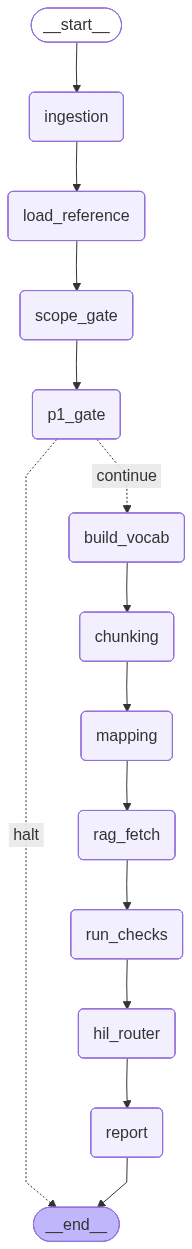

In [169]:
compiled_graph

In [166]:
start_workflow_state = WorkflowState(
    document_paths= [str(file) for file in files[:1]],
    chunk_chars= 1200,
    overlap_chars= 200,
)

In [171]:
out = compiled_graph.invoke(start_workflow_state)

Mapping bundle size 7
Mapping max bundles 0
Bundle count 0
Bundle count 1
Bundle count 2
Bundle count 3
Bundle count 4
Bundle count 5


In [172]:
out 

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200,
 'documents': ['Welcome to Patreon!\nPatreon is a platform where patrons can support and engage with creators. This \xa0updated Privacy Policy applies to patrons, creators, and all users of our platform, and is part of our Terms of Use.\nPatreon is a global company. By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your use of the platform, may be transferred to and stored in the United States and handled as described in this Policy.\nInformation You Provide Through Your Account\nThis is information that you provide to us through text fields, such as your name, payment information and benefits. The information we collect differs depending on if you make an account, become a patron, or become a creator.\nFirst and Last Name\nEmail Address\nUsername\nPassword\nState and Country of Residence\nYou may also sig

In [173]:
pprint.pp(out)

{'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml'],
 'chunk_chars': 1200,
 'overlap_chars': 200,
 'documents': ['Welcome to Patreon!\n'
               'Patreon is a platform where patrons can support and engage '
               'with creators. This \xa0updated Privacy Policy applies to '
               'patrons, creators, and all users of our platform, and is part '
               'of our Terms of Use.\n'
               'Patreon is a global company. By using our platform, you agree '
               'that your personal information that you provide directly to '
               'us, or that we collect through your use of the platform, may '
               'be transferred to and stored in the United States and handled '
               'as described in this Policy.\n'
               'Information You Provide Through Your Account\n'
               'This is information that you provide to us through text '
               'fields, such as your name, payment information and benefits.

In [174]:
out['report']

{'halted': False,
 'inputs': {'document_paths': ['../data/post_gdpr/data/GoPPC-150/88.xml']},
 'scope': {'applies': 'yes',
  'reasons': ['The company is global and mentions data may be transferred to the United States, but the policy applies to users regardless of location, suggesting processing of data of individuals in the Union.',
   'The company collects personal information such as name, email, state, and country of residence, which are considered personal data under GDPR.',
   "The policy explicitly states it applies to 'all users of our platform,' which can include individuals within the EU.",
   "The policy mentions 'offering of goods or services' through the platform, which aligns with GDPR Art. 3(2)(a) for controllers/processors not established in the Union targeting data subjects in the Union."],
  'evidence': ['Patreon is a global company.',
   'By using our platform, you agree that your personal information that you provide directly to us, or that we collect through your u